<a href="https://colab.research.google.com/github/saini18-eng/project-task/blob/flow/Credit_Card_Transactions_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install scikit-learn pandas matplotlib seaborn


In [6]:
from google.colab import files
uploaded = files.upload()


Saving Credit Card Transactions Fraud Detection.zip to Credit Card Transactions Fraud Detection.zip


In [7]:
import zipfile
import os

zip_path = "Credit Card Transactions Fraud Detection.zip"  # Change this if your file has a different name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")  # Extracts into the "dataset" folder


In [8]:
os.listdir("dataset")


['fraudTest.csv', 'fraudTrain.csv']

In [9]:
import pandas as pd

df = pd.read_csv("dataset/fraudTrain.csv")
df.head()


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


📊 Step 4: Dataset Exploration

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

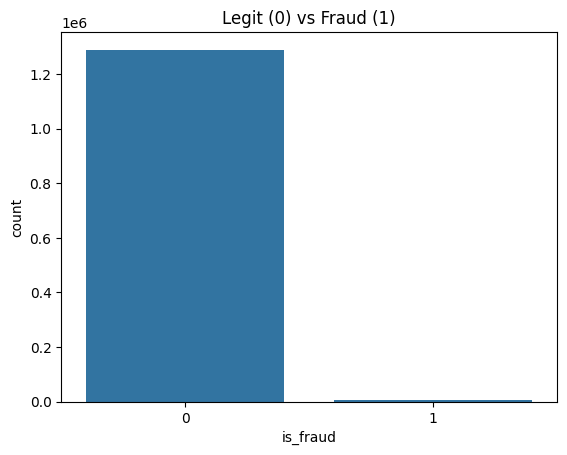

In [11]:
# Data Info
print(df.info())
print(df['is_fraud'].value_counts())

# Class distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_fraud', data=df)
plt.title("Legit (0) vs Fraud (1)")
plt.show()

⚙️ Step 5: Data Preprocessing

In [14]:
# Features and Target
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

# Select only numerical columns for scaling
X_numeric = X.select_dtypes(include=['number'])

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

🔀 Step 6: Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1037340, 10)
Shape of X_test: (259335, 10)
Shape of y_train: (1037340,)
Shape of y_test: (259335,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)


🤖 Step 7: Train Models

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)


RandomForestClassifier()

🧪 Step 8: Evaluate Models

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(name, model):
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate_model("Logistic Regression", lr)
evaluate_model("Decision Tree", dt)
evaluate_model("Random Forest", rf)



Logistic Regression
[[386537    214]
 [  2252      0]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    386751
           1       0.00      0.00      0.00      2252

    accuracy                           0.99    389003
   macro avg       0.50      0.50      0.50    389003
weighted avg       0.99      0.99      0.99    389003


Decision Tree
[[385303   1448]
 [  1246   1006]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.41      0.45      0.43      2252

    accuracy                           0.99    389003
   macro avg       0.70      0.72      0.71    389003
weighted avg       0.99      0.99      0.99    389003


Random Forest
[[386547    204]
 [  1179   1073]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.84      0.48      0.61      2252

    accuracy              

In [ ]:
📄 Step 9: Save as requirements.txt

In [32]:
with open("requirements.txt", "w") as f:
    f.write("pandas\nscikit-learn\nseaborn\nmatplotlib\nimblearn")
